In [1]:
import torch 
from torch .utils.data import Dataset, DataLoader
import numpy as np
from torchvision import transforms
import pandas as pd
import os
import pickle
import cv2
import matplotlib.pyplot as plt
from torch import nn
import gc

In [6]:
import os
import cv2
import pickle
import numpy as np
import pandas as pd
from torch.utils.data import Dataset

class MRIdataset_YOLO(Dataset):
    def __init__(self, rootdir, metadata, target_size=(320, 320),
                 transform=None, target_transform=None, max_files=50):
        self.rootdir = rootdir
        self.data = pd.read_csv(metadata)
        self.transform = transform
        self.target_transform = target_transform
        self.target_size = target_size
        self.max_files = max_files

        # limit number of volumes
        volumes = self.data['volumeFilename'].unique()[:self.max_files]
        self.volumes_data = self.data[self.data['volumeFilename'].isin(volumes)]

        self.samples = []
        for _, row in self.volumes_data.iterrows():
            pickle_file_root = os.path.join(self.rootdir, row['volumeFilename'])
            with open(pickle_file_root, 'rb') as f:
                slices = pickle.load(f)  # shape: (num_slices, H, W)

            z_start = int(row['roiZ'])
            depth = int(row['roiDepth'])

            for slice_idx in range(z_start, z_start + depth):
                image = slices[slice_idx, :, :]
                # add (class_id, x, y, w, h)
                self.samples.append((
                    image,
                    (0, row['roiX'], row['roiY'], row['roiWidth'], row['roiHeight'])
                ))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        image = self.samples[idx][0].astype(np.float32)
        image = cv2.normalize(image, None, 0, 255, cv2.NORM_MINMAX)
        image = image.astype(np.uint8)
        label = self.samples[idx][1]  # (class_id, x, y, w, h)
        
        # --- Resize image ---
        orig_h, orig_w = image.shape[:2]
        image = cv2.resize(image, self.target_size, interpolation=cv2.INTER_LINEAR)
        new_w, new_h = self.target_size

        # --- Normalize bounding box ---
        class_id, x, y, w, h = label

        # scale bbox to new size
        scale_x = new_w / orig_w
        scale_y = new_h / orig_h
        x *= scale_x
        y *= scale_y
        w *= scale_x
        h *= scale_y

        # convert to YOLO normalized format (center_x, center_y, w, h in [0,1])
        x_center = (x + w / 2) / new_w
        y_center = (y + h / 2) / new_h
        w_norm = w / new_w
        h_norm = h / new_h

        norm_label = (class_id, x_center, y_center, w_norm, h_norm)

        # --- Apply transforms if needed ---
        if self.transform:
            image = self.transform(image)
        if self.target_transform:
            norm_label = self.target_transform(norm_label)

        return image, norm_label


In [7]:
dataset_test=MRIdataset_YOLO(rootdir='./MRI_dataset/volumetric_data/',metadata='./MRI_dataset/metadata.csv',max_files=400)
print(f"Size of dataset: {len(dataset_test)}")
image_test,label_test=dataset_test[2]
print(f'Image shape: {image_test.shape}, Label: {label_test}')
print(f"image type: {type(image_test)}, label ty pe: {type(label_test)}")

Size of dataset: 1316
Image shape: (320, 320), Label: (0, 0.546875, 0.690625, 0.225, 0.23125)
image type: <class 'numpy.ndarray'>, label ty pe: <class 'tuple'>


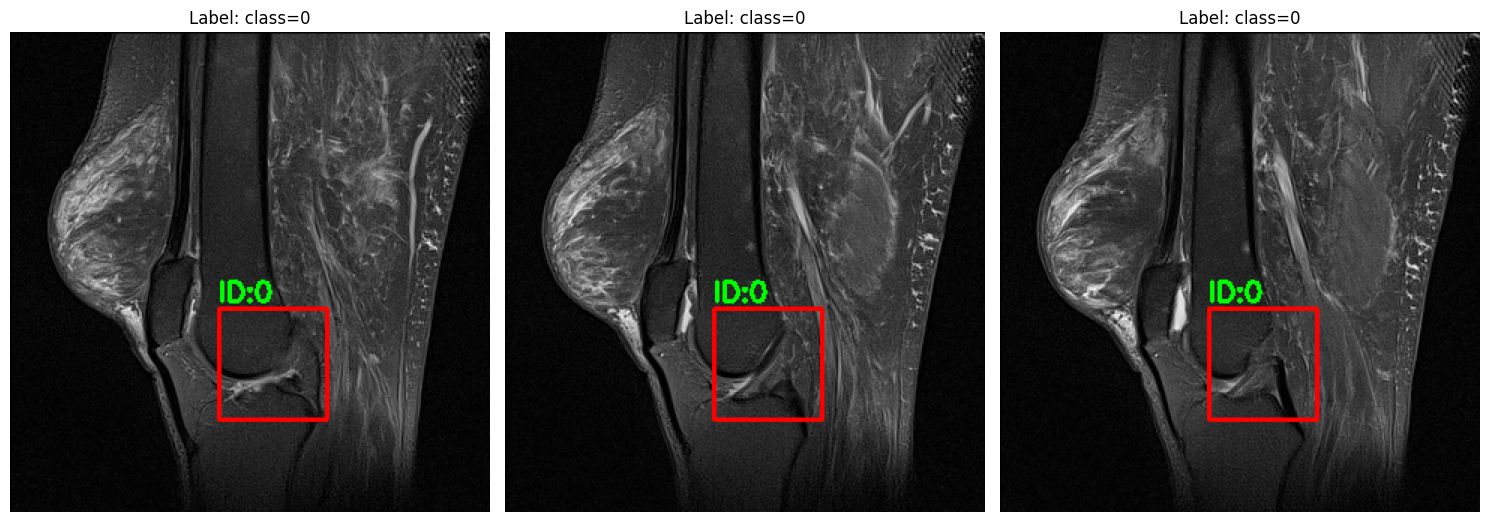

In [8]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

num_show = 3
figure = plt.figure(figsize=(15, 7))

for i in range(num_show):
    img, label = dataset_test[i]
    class_id, x_center, y_center, w_norm, h_norm = label

    # convert to numpy if tensor
    if not isinstance(img, np.ndarray):
        img = img.numpy()
        if img.ndim == 3 and img.shape[0] in [1, 3]:  # (C,H,W)
            img = np.transpose(img, (1, 2, 0))

    # normalize grayscale range to 0–255 (for display)
    

    # convert to 3-channel for drawing bbox
    if img.ndim == 2:
        img_color = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    else:
        img_color = img.copy()

    h, w = img.shape[:2]
    
    # denormalize bbox
    x_center *= w
    y_center *= h
    w_box = w_norm * w
    h_box = h_norm * h
    x1 = int(x_center - w_box / 2)
    y1 = int(y_center - h_box / 2)
    x2 = int(x_center + w_box / 2)
    y2 = int(y_center + h_box / 2)

    # draw bbox
    cv2.rectangle(img_color, (x1, y1), (x2, y2), (0, 0, 255), 2)
    cv2.putText(img_color, f"ID:{int(class_id)}", (x1, y1 - 5),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

    # plot in grayscale but show box color
    ax = figure.add_subplot(1, num_show, i + 1)
    ax.imshow(cv2.cvtColor(img_color, cv2.COLOR_BGR2RGB))
    ax.set_title(f"Label: class={int(class_id)}")
    ax.axis("off")

plt.tight_layout()
plt.show()


In [9]:
import os
import cv2
import yaml
import numpy as np
from sklearn.model_selection import train_test_split

def build_yolo_dataset(dataset, save_dir="yolo_dataset", val_split=0.2, img_ext=".jpg", class_names=None):
    """
    Convert a custom PyTorch dataset (with (image, label)) to YOLOv8-compatible folder structure.

    Args:
        dataset: iterable returning (image, label), where label = [class, x_center, y_center, w, h] (normalized)
        save_dir: root output directory for YOLO dataset
        val_split: fraction of data for validation
        img_ext: image extension (.jpg or .png)
        class_names: optional list of class names
    """
    # 1. Split train/val
    indices = np.arange(len(dataset))
    train_idx, val_idx = train_test_split(indices, test_size=val_split, random_state=42)

    # 2. Define subfolders
    paths = {
        "images_train": os.path.join(save_dir, "images", "train"),
        "images_val": os.path.join(save_dir, "images", "val"),
        "labels_train": os.path.join(save_dir, "labels", "train"),
        "labels_val": os.path.join(save_dir, "labels", "val"),
    }
    for p in paths.values():
        os.makedirs(p, exist_ok=True)

    # 3. Helper: save one sample
    def save_sample(i, img, label, split="train"):
        img_name = f"{i:06d}{img_ext}"
        label_name = f"{i:06d}.txt"

        img_path = os.path.join(save_dir, "images", split, img_name)
        label_path = os.path.join(save_dir, "labels", split, label_name)

        # convert tensor to numpy
        if not isinstance(img, np.ndarray):
            img = img.numpy()
            if img.ndim == 3 and img.shape[0] in [1, 3]:
                img = np.transpose(img, (1, 2, 0))

        # normalize to 0–255
        img = cv2.normalize(img.astype(np.float32), None, 0, 255, cv2.NORM_MINMAX)
        img = img.astype(np.uint8)

        # convert grayscale to 3 channels
        if img.ndim == 2:
            img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

        cv2.imwrite(img_path, img)

        # write label (already normalized)
        cls, x, y, w, h = label
        with open(label_path, "w") as f:
            f.write(f"{int(cls)} {x:.6f} {y:.6f} {w:.6f} {h:.6f}\n")

    # 4. Save images and labels
    for i in train_idx:
        img, label = dataset[i]
        save_sample(i, img, label, "train")

    for i in val_idx:
        img, label = dataset[i]
        save_sample(i, img, label, "val")

    # 5. Create dataset.yaml
    yaml_path = os.path.join(save_dir, "dataset.yaml")
    data_yaml = {
        "train": os.path.abspath(os.path.join(save_dir, "images", "train")),
        "val": os.path.abspath(os.path.join(save_dir, "images", "val")),
        "nc": len(class_names) if class_names else 1,
        "names": class_names if class_names else ["class_0"]
    }
    with open(yaml_path, "w") as f:
        yaml.dump(data_yaml, f)

    print(f"✅ YOLO dataset ready at: {save_dir}")
    print(f"   train: {len(train_idx)} images")
    print(f"   val:   {len(val_idx)} images")
    print(f"   YAML:  {yaml_path}")
    return yaml_path

In [10]:
yaml_path = build_yolo_dataset(
    dataset=dataset_test,
    save_dir="MRI_YOLO",
    val_split=0.2,
    class_names=["AcL", "NON_ACL"]
)

✅ YOLO dataset ready at: MRI_YOLO
   train: 1052 images
   val:   264 images
   YAML:  MRI_YOLO\dataset.yaml


In [ ]:
from ultralytics import YOLO
model = YOLO(model='yolov8n.pt')
# Train on your dataset
model.train(
    data='./MRI_YOLO/dataset.yaml',
    epochs=30,
    imgsz=320,
    batch=64,
    patience=10,
)


Ultralytics 8.3.225  Python-3.13.5 torch-2.9.0+cu126 CUDA:0 (NVIDIA GeForce RTX 4090, 24564MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=./MRI_YOLO/dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train4, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=5, perspective=0.0, plots=True,

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x00000226AD5BABA0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.0480

In [ ]:
import torch
import torch.nn as nn
class LigamentIsolationCNN(nn.Module):
    def __init__(self, para):
        super(LigamentIsolationCNN, self).__init__()
        self.input_channel = para['input_channel']
        self.input_size = para['input_size']
        self.num_classes = para['num_classes']
        self.features = nn.Sequential(
            # 1️⃣ First Block
            nn.Conv2d(self.input_channel, 64, kernel_size=7, stride=1, padding=3),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # 2️⃣ Second Block
            nn.Conv2d(64, 192, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(192),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # 3️⃣ Third Block
            nn.Conv2d(192, 128, kernel_size=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # 4️⃣ Fourth Block
            *self.loop_conv_block(512, 256, 4),
            nn.Conv2d(512, 512, kernel_size=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.Conv2d(512, 1024, kernel_size=3, padding=1),
            nn.BatchNorm2d(1024),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # 5️⃣ Fifth Block
            *self.loop_conv_block(1024, 512, 2),
            nn.Conv2d(1024, 1024, kernel_size=3, padding=1),
            nn.BatchNorm2d(1024),
            nn.ReLU(),
            *self.loop_conv_block(1024, 512, 4)
        )

        # 6️⃣ Fully Connected + Output
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(self._get_flattened_size(), 4096),
            nn.ReLU(),
            nn.Linear(4096, 7 * 7 * 11),
            nn.Sigmoid()
        )

    def loop_conv_block(self, in_channels, mid_channels, n):
        layers = []
        for _ in range(n):
            layers += [
                nn.Conv2d(in_channels, mid_channels, kernel_size=1),
                nn.BatchNorm2d(mid_channels),
                nn.ReLU(),
                nn.Conv2d(mid_channels, in_channels, kernel_size=3, padding=1),
                nn.BatchNorm2d(in_channels),
                nn.ReLU(),
            ]
        return layers

    def _get_flattened_size(self):
        with torch.no_grad():
            x = torch.randn(1, self.input_channel, *self.input_size)
            x = self.features(x)
            return x.flatten(1).shape[1]

    def forward(self, x):
        x = self.features(x)
        x = self.fc(x)
        x = x.view(-1, 7, 7, 11)
        return x


if __name__ == "__main__":
    para = {
        'input_channel': 1,
        'input_size': (320, 320),
        'num_classes': 1
    }
    device = 'cuda' if torch.cuda.is_available() else 'cpu'

    with torch.no_grad():
        model = LigamentIsolationCNN(para).to(device)
        x = torch.randn(1, 1, 320, 320).to(device)
        y = model(x)
        print("✅ Output shape:", y.shape)  # Expect [1, 7, 7, 11]

        # 🧠 Count parameters
        total_params = sum(p.numel() for p in model.parameters())
        trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

        print(f"\n🧩 Total parameters: {total_params:,}")
        print(f"🎯 Trainable parameters: {trainable_params:,}")
        print(f"💾 Model size ≈ {total_params * 4 / 1e6:.2f} MB (FP32)")
    

✅ Output shape: torch.Size([1, 7, 7, 11])

🧩 Total parameters: 1,732,779,227
🎯 Trainable parameters: 1,732,779,227
💾 Model size ≈ 6931.12 MB (FP32)
